### imports/data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from astropy.table import Table, vstack,hstack
import numpy.ma as ma
import matplotlib.cm as cm

import emcee
import corner

# import marvin
import pyneb as pn
import sys
sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/ellipticals')
from elliptical_plottingFunctions import *
from IO_data import *
from elliptical_stellar_mass import calc_mass_curve
from elliptical_stellar_mass_functions import exponential_disk, exponential_sphere, exponential_sphere_disk
from matplotlib.lines import Line2D

from scipy.optimize import curve_fit
from scipy.optimize import minimize

sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/spirals')
from SHMR_functions import shmr_RP11



In [3]:
master_table_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_illustris_v10.fits'

master_table = Table.read(master_table_fn)
master_table[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,nsa_elpetro_log_mass,rabsmag,param_H2_R90,logHe,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,BPT_class,spiral_mask,elliptical_mask,Age_LW_Re_fit,Age_MW_Re_fit,ZH_LW_Re_fit,ZH_MW_Re_fit,M90_disk_h,M90_disk_err_h,sphd_M_star_err_h,sphd_M_star_h,V_R90,V_R90_err,e_M_star_R90,e_M_star_R90_err,e_M_star_R90_h,e_M_star_R90_err_h,v_eff,v_eff_err,logHI,logHI_err,HI_catalog,logHI_h,logHI_err_h,N2Ha,O3Hb,nsa_u_r,illustris_match,illustris_dist,illustris_u_r,illustris_Mstar,illustris_Mstar_Sal,illustris_Vmax,illustris_flag,illustris_MR90,MH2_S14_vol,MHI_S14_vol,MHtot
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,

In [4]:
master_table_dict = {}
for i in range(len(master_table)):
    master_table_dict[master_table['plateifu'][i]] = i

In [5]:
PIPE3D_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Pipe3D/'
DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'
VEL_FOLDER = DATA_FOLDER + 'DR17/'


matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300

In [6]:
plot_dir = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/paper_plots/final/gaussian_fits/'

In [7]:
ellipticals = master_table[master_table['elliptical_mask']==1]
spirals = master_table[master_table['spiral_mask']==1]

In [8]:
nsa_portsmouth = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/NSA_v1_0_1_vflag_Portsmouth.fits')
nsa_portsmouth[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,u_r,g_r,NUV_r,index,imc,aimc,cd,conx1,u_r_KIAS,prmag,BPTclass,SFR,sSFR,HImass,vflag,u_r_err,g_r_err,NUV_r_err,ID,Flux_OII_3726,Flux_OII_3726_Err,AoN_OII_3726,Flux_OII_3728,Flux_OII_3728_Err,AoN_OII_3728,Flux_OIII_4363,Flux_OIII_4363_Err,AoN_OIII_4363,Flux_Hb_4861,Flux_Hb_4861_Err,AoN_Hb_4861,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,AoN_OIII_5006,Flux_NI_5197,Flux_NI_5197_Err,AoN_NI_5197,Flux_NI_5200,Flux_NI_5200_Err,AoN_NI_5200,Flux_OI_6300,Flux_OI_6300_Err,AoN_OI_6300,Flux_OI_6363,Flux_OI_6363_Err,AoN_OI_6363,Flux_NII_6547,Flux_NII_6547_Err,Flux_Ha_6562,Flux_Ha_6562_Err,AoN_Ha_6562,Flux_NII_6583,Flux_NII_6583_Err,AoN_NII_6583,Flux_SII_6716,Flux_SII_6716_Err,AoN_SII_6716,Flux_SII_6730,Flux_SII_6730_Err,AoN_SII_6730
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float32,float32,float32,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J023211.77+001326.5,02h/p00/J023211.77+001326.5,38.04906209256324,0.22402153989646575,39438,22721,-1,-1,71327,-1,16.771198,0.054021582,sdss,0.07,109,4,23,301,1960.5631,83.361275,38979,0.054392263,1.3420134 .. 884.58374,16.215242 .. 0.0016165179,1,1.4780203 .. 964.8986,-13.908231 .. -21.045618,24.77356 .. 1073.0248,0.2271526 .. 0.04052578,-0.060923357 .. 0.029009609,1.4557369e-05 .. 1.222673e-15,0.0016189957 .. 1.23927,2.5023096e-06,0.06656253,0.024689334,22540354000.0,156.48558044433594,201.36697387695312,10 .. 11,0.016490662 .. 0.0,5489.7393 .. 0.0,0.21582535 .. -0.09177922,0.0076095443 .. 0.15974313,0.64479166 ..

In [9]:
nsa_dict = {}
for i in range(len(nsa_portsmouth)):
    nsa_dict[nsa_portsmouth['NSAID'][i]] = i

In [10]:
G = 4.3009 * 10**-6 # [kpc (km/s)^2 / M_sun]
H_0 = 100 # [km / s / Mpc]
c = 299792.458 # Speed of light in units of km/s

In [11]:
blue_spirals = spirals[spirals['CMD_class'] == 1]
green_spirals = spirals[spirals['CMD_class']==2]
red_spirals = spirals[spirals['CMD_class']==3]

In [13]:
mcg = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/McGaugh_2012.csv', format='csv')
mcg[:5]

Galaxy,D,V_f,V_f_err,Mstar,Mstar_err,Mg,Mg_err
str8,float64,int64,int64,float64,float64,float64,float64
DDO 210,0.94,17,4,5.88,0.15,6.64,0.2
Cam B,3.34,20,12,6.99,0.15,7.33,0.2
UGC 8215,4.5,20,6,6.81,0.15,7.45,0.2
DDO 183,3.24,25,3,7.24,0.15,7.54,0.2
UGC 8833,3.2,27,4,6.94,0.15,7.3,0.2


In [14]:
torflor = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/torres_flores_2011.csv', format='csv')
torflor[:5]

Galaxy UGC,Mbar,Mbar_err,V_TF,V_TF_err
int64,float64,float64,int64,int64
89,11.37,0.1,343,117
94,10.72,0.08,209,21
763,9.81,0.06,104,11
1317,11.23,0.09,205,9
2141,9.82,0.08,157,20


In [15]:
i_sample = master_table[master_table['illustris_match'] >= 0]

In [16]:
HI_spirals = spirals[spirals['logHI_h']>0]
HI_spirals['Mstar_MHI_h'] = np.log10(10**HI_spirals['sphd_M_star_h'] + 10**HI_spirals['logHI_h'])
HI_spirals['Mstar_MHI_err_h'] = 0.5*np.log10((10**HI_spirals['sphd_M_star_err_h'])**2 + (10**HI_spirals['logHI_err_h'])**2)

In [20]:
HI_s_match = master_table[np.logical_and(np.logical_and(master_table['logHI_h'] > 0, master_table['spiral_mask']==1),
                                         master_table['illustris_match'] >= 0)]

HI_s_match['Mstar_MHI_h'] = np.log10(10**HI_s_match['sphd_M_star_h'] + 10**HI_s_match['logHI_h'])
HI_s_match['Mstar_MHI_err_h'] = 0.5*np.log10((10**HI_s_match['sphd_M_star_err_h'])**2 + (10**HI_s_match['logHI_err_h'])**2)

HI_s_match['illustris_Mstar_MHI_h'] = np.log10(10**HI_s_match['illustris_Mstar_Sal'] + 10**HI_s_match['MHI_S14_vol'])

In [23]:
s_match = master_table[np.logical_and(master_table['spiral_mask']==1, master_table['illustris_match']>=0)]
e_match = master_table[np.logical_and(master_table['elliptical_mask']==1, master_table['illustris_match']>=0)]

### functions

In [12]:
def lin_fit(x, a, b):

    return a*x + b

def lin_fit_fixed_slope(x, b):

    return x + b

def chi2_norm(model, data, err, dof):

    return np.sum(((model-data)/err)**2)/(len(data)-dof)

In [30]:
def logl(params, x, y, dy):

    '''
    PARAMETERS
    ==========

    a : slope
    b : y int
    
    '''

    a, b = params

    model = a * x + b

    return -0.5 * np.sum((y-model)**2/dy**2 + np.log(2*np.pi*dy**2))

def log_prior(params):

    a, b = params
    if -10 < a < 10 and -10 < b < 10:
        return 0.

    return -np.inf

def log_prob(params, x, y, dy):

    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf

    return lp + logl(params, x, y, dy)
    

## BTFR setup

In [24]:
v_eff_bins = np.linspace(np.min([np.log10(np.min(ellipticals['v_eff'])), np.log10(np.min(HI_spirals['V_R90']))]),
                         np.max([np.log10(np.max(ellipticals['v_eff'])), np.log10(np.max(HI_spirals['V_R90']))]),
                         15)

In [25]:
min_mvis = np.min([np.min(HI_s_match['Mstar_MHI_h']), np.min(HI_s_match['illustris_Mstar_MHI_h']),
                   np.min(e_match['sphd_M_star_h']), np.min(e_match['illustris_Mstar_Sal'])])

max_mvis = np.max([np.max(HI_s_match['Mstar_MHI_h']), np.max(HI_s_match['illustris_Mstar_MHI_h']),
                   np.max(e_match['sphd_M_star_h']), np.max(e_match['illustris_Mstar_Sal'])])

mvis_bins = np.linspace(min_mvis, max_mvis + 0.1, 15)

## BTFR fits

### MaNGA ellipticals

In [363]:
e_veff = []
e_veff_ctr = []
e_mvis_bins = mvis_bins
e_mvis_bins = np.concatenate((mvis_bins[:1], mvis_bins[4:-4], mvis_bins[-1:]))
indices = np.digitize(e_match['sphd_M_star_h'], e_mvis_bins)

for i in range(1, len(e_mvis_bins)):

    e_veff.append(np.log10(e_match['v_eff'])[indices==i])
    e_veff_ctr.append(np.mean(e_match['sphd_M_star_h'][indices==i]))

e_mvis_veff_avg, e_mvis_veff_sig = fit_to_gaussian(e_veff, plot_dir = plot_dir +'/e_mvis_veff_imatch/', 
                                                         plot_name='e_v_eff_mvis', xlab=r'$M_{\rm vis}$')

e_mvis_veff_popt, e_mvis_veff_pcov = curve_fit(lin_fit, e_veff_ctr, 
                                       e_mvis_veff_avg, sigma=e_mvis_veff_sig)

print('best fit values: ')
print(e_mvis_veff_popt[0], ' +- ', np.sqrt(e_mvis_veff_pcov[0,0]))
print(e_mvis_veff_popt[1], ' +- ', np.sqrt(e_mvis_veff_pcov[1][1]))
print('slope: ', 1/e_mvis_veff_popt[0], ' +/- ', 1/e_mvis_veff_popt[0]**2 * e_mvis_veff_pcov[0,0])
err = np.sqrt(e_mvis_veff_pcov[1,1]**2/e_mvis_veff_popt[0]**2 +(e_mvis_veff_popt[1]/e_mvis_veff_popt[0]**2)**2 * e_mvis_veff_pcov[0,0]**2)
print('y-int: ', -e_mvis_veff_popt[1]/e_mvis_veff_popt[0], ' +/- ', err)
e_chi2_norm = chi2_norm(e_mvis_veff_avg, e_mvis_veff_popt[0]*np.array(e_veff_ctr) + e_mvis_veff_popt[1], e_mvis_veff_sig, 2)
print('chi2_nu: ', e_chi2_norm)

best fit values: 
0.2997842800866165  +-  0.01138185233523094
-0.8558261211938906  +-  0.1249538173291214
slope:  3.3357319460215544  +/-  0.001441478543083957
y-int:  2.854806532706175  +/-  0.05209691404257196
chi2_nu:  6.100646250996397


#### MCMC

In [364]:
x0 = np.random.uniform(low=[-10,-10], high=[10,10], size=(32,2))
nwalkers, ndim = x0.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=(np.array(e_veff_ctr), e_mvis_veff_avg, e_mvis_veff_sig))
state = sampler.run_mcmc(x0, 10000, progress='notebook')

  0%|          | 0/10000 [00:00<?, ?it/s]

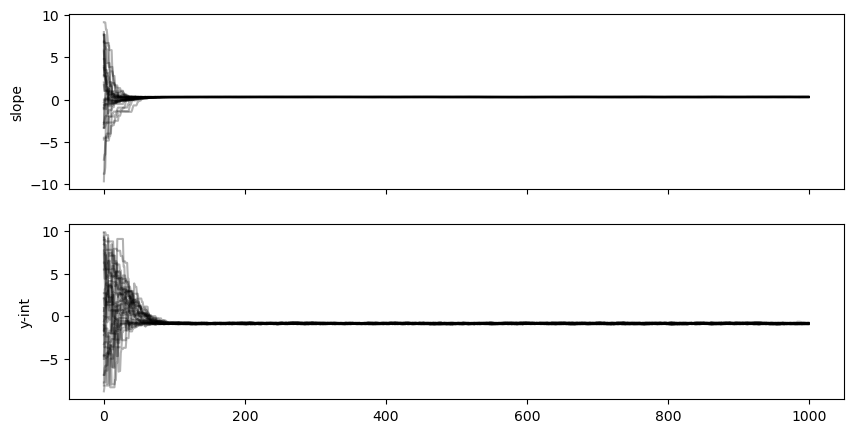

In [365]:
fig, axes = plt.subplots(2,1, figsize=(10,5), sharex=True, gridspec_kw={'hspace':0.2})
samples = sampler.get_chain()
labels = ['slope', 'y-int']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:1000, :, i], 'k', alpha=0.3)
    ax.set_ylabel(labels[i])
    

In [366]:
tau = sampler.get_autocorr_time()
flat_samples = sampler.get_chain(discard=100, thin=int(np.max(tau)), flat=True)

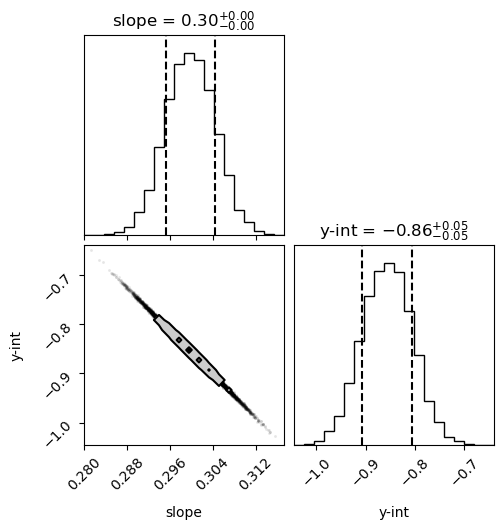

In [367]:
fig = corner.corner(flat_samples, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84]
                   # plot_density=1
                   )



In [368]:
flat_samples_flip = np.array([1/flat_samples[:,0], -flat_samples[:,1]/flat_samples[:,0]]).transpose()

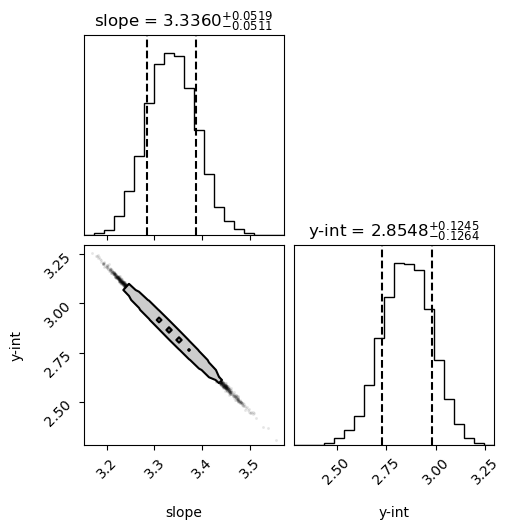

In [369]:
fig = corner.corner(flat_samples_flip, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                    title_fmt='.4f'
                   # plot_density=1
                    
                   )

plt.savefig(plot_dir + '/paper_plots/' + 'manga_ellipticals_corner.png', bbox_inches='tight')

#### fixed slope

In [378]:
e_slope = np.percentile(flat_samples[:,0],50)
e_yint = np.percentile(flat_samples[:,1],50)
e_chi2 = chi2_norm(lin_fit(np.array(e_veff_ctr), np.percentile(flat_samples[:,0],50), np.percentile(flat_samples[:,1],50)), e_mvis_veff_avg, e_mvis_veff_sig, 2)

In [379]:
bs = np.linspace(-0.9,-0.6,10000)
e_chi2_fixed = np.zeros(len(bs))
for i in range(len(bs)):
    e_chi2_fixed[i] = chi2_norm(lin_fit(np.array(e_veff_ctr), e_slope, bs[i]), e_mvis_veff_avg, e_mvis_veff_sig, 1)

In [380]:
e_yint_fixed = bs[np.argmin(e_chi2_fixed)]
e_chi2_fixed_min = np.min(e_chi2_fixed)
print(np.min(e_chi2_fixed))
print(bs[np.argmin(e_chi2_fixed)])

5.229132693574292
-0.8555655565556556


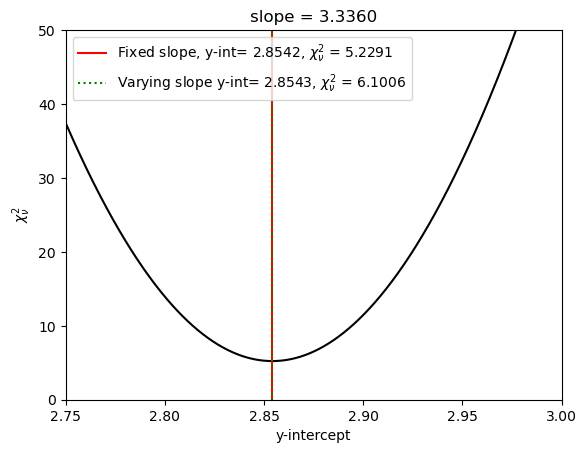

In [381]:
plt.plot(-bs/e_slope, e_chi2_fixed, color='k')
plt.axvline(-e_yint_fixed/e_slope, color='r', label=fr'Fixed slope, y-int= {-e_yint_fixed/e_slope:.4f}, $\chi^2_\nu$ = {e_chi2_fixed_min:.4f}')
plt.axvline(-e_yint/e_slope, color='g', linestyle=':', label=fr'Varying slope y-int= {-e_yint/e_slope:.4f}, $\chi^2_\nu$ = {e_chi2_norm:.4f}')
plt.legend()
plt.xlabel('y-intercept')
plt.ylabel(r'$\chi^2_\nu$')
plt.title(f'slope = {1/e_slope:.4f}')
plt.xlim(2.75,3)
plt.ylim(0,50)
plt.savefig(plot_dir + '/paper_plots/' + 'manga_ellipticals_chi2.png', bbox_inches='tight')

### Illustris TNG ellipticals

In [382]:
ie_veff = []
ie_veff_ctr = []
ie_mvis_bins = mvis_bins
ie_mvis_bins = np.concatenate((mvis_bins[:1], mvis_bins[4:-4], mvis_bins[-1:]))
indices = np.digitize(e_match['illustris_Mstar_Sal'], ie_mvis_bins)

for i in range(1, len(ie_mvis_bins)):

    ie_veff.append(np.log10(e_match['v_eff'])[indices==i])
    ie_veff_ctr.append(np.mean(e_match['illustris_Mstar_Sal'][indices==i]))

ie_mvis_veff_avg, ie_mvis_veff_sig = fit_to_gaussian(ie_veff, plot_dir = plot_dir +'/ie_mvis_veff_imatch/', 
                                                         plot_name='e_v_eff_mvis', xlab=r'$M_{\rm vis}$')

ie_mvis_veff_popt, ie_mvis_veff_pcov = curve_fit(lin_fit, ie_veff_ctr, 
                                       ie_mvis_veff_avg, sigma=ie_mvis_veff_sig)

print('best fit values: ')
print(ie_mvis_veff_popt[0], ' +- ', np.sqrt(ie_mvis_veff_pcov[0,0]))
print(ie_mvis_veff_popt[1], ' +- ', np.sqrt(ie_mvis_veff_pcov[1][1]))
print('slope: ', 1/ie_mvis_veff_popt[0], ' +/- ', 1/ie_mvis_veff_popt[0]**2 * ie_mvis_veff_pcov[0,0])
err = np.sqrt(ie_mvis_veff_pcov[1,1]**2/ie_mvis_veff_popt[0]**2 +(ie_mvis_veff_popt[1]/ie_mvis_veff_popt[0]**2)**2 * ie_mvis_veff_pcov[0,0]**2)
print('y-int: ', -ie_mvis_veff_popt[1]/ie_mvis_veff_popt[0], ' +/- ', err)
ie_chi2_norm = chi2_norm(ie_mvis_veff_avg, ie_mvis_veff_popt[0]*np.array(ie_veff_ctr) + ie_mvis_veff_popt[1], ie_mvis_veff_sig, 2)
print('chi2_nu: ', ie_chi2_norm)

best fit values: 
0.2969156391817638  +-  0.011438952836069707
-0.8237967623939806  +-  0.1255096146765339
slope:  3.3679600130049967  +/-  0.0014842477248377718
y-int:  2.7745145545859047  +/-  0.05306842818835892
chi2_nu:  6.336027577606624


#### MCMC

In [383]:
x0 = np.random.uniform(low=[-10,-10], high=[10,10], size=(32,2))
nwalkers, ndim = x0.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=(np.array(ie_veff_ctr), ie_mvis_veff_avg, ie_mvis_veff_sig))
state = sampler.run_mcmc(x0, 10000, progress='notebook')

  0%|          | 0/10000 [00:00<?, ?it/s]

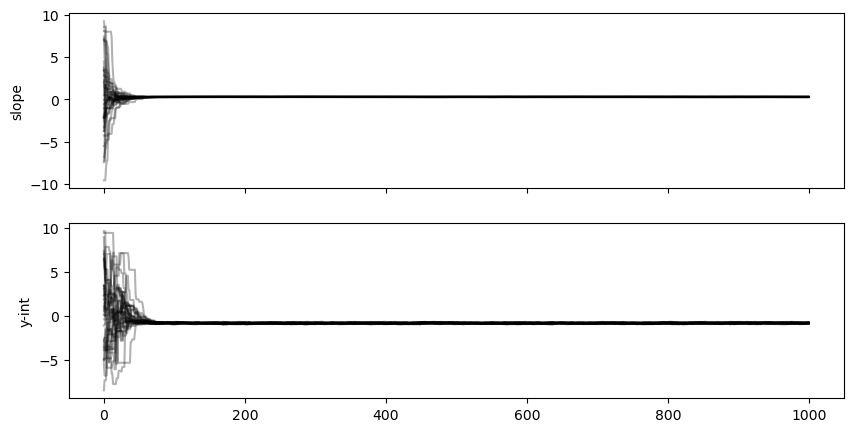

In [384]:
fig, axes = plt.subplots(2,1, figsize=(10,5), sharex=True, gridspec_kw={'hspace':0.2})
samples = sampler.get_chain()
labels = ['slope', 'y-int']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:1000, :, i], 'k', alpha=0.3)
    ax.set_ylabel(labels[i])

In [385]:
tau = sampler.get_autocorr_time()
flat_samples = sampler.get_chain(discard=100, thin=int(np.max(tau)), flat=True)

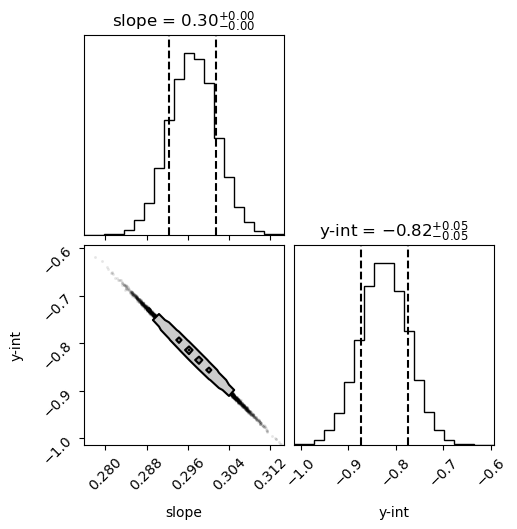

In [386]:
fig = corner.corner(flat_samples, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84]
                   # plot_density=1
                   )

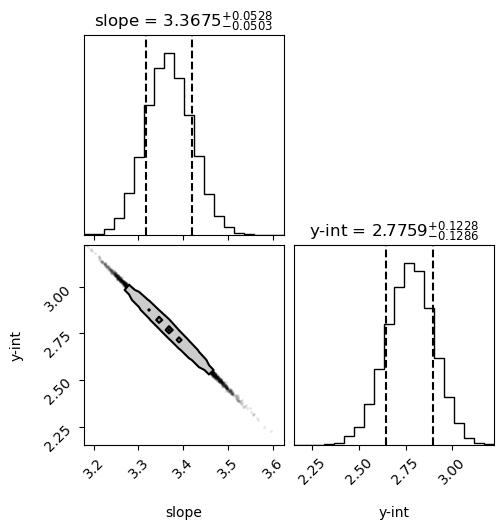

In [387]:
flat_samples_flip = np.array([1/flat_samples[:,0], -flat_samples[:,1]/flat_samples[:,0]]).transpose()
fig = corner.corner(flat_samples_flip, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                    title_fmt='.4f'
                   # plot_density=1
                    
                   )

plt.savefig(plot_dir + '/paper_plots/' + 'illustris_ellipticals_corner.png', bbox_inches='tight')

In [388]:
ie_slope = np.percentile(flat_samples[:,0],50)
ie_yint = np.percentile(flat_samples[:,1],50)
ie_chi2 = chi2_norm(lin_fit(np.array(ie_veff_ctr), np.percentile(flat_samples[:,0],50), np.percentile(flat_samples[:,1],50)), ie_mvis_veff_avg, ie_mvis_veff_sig, 2)
ie_chi2

6.336816116570925

In [389]:
bs = np.linspace(-1,-0.5,10000)
ie_chi2_fixed = np.zeros(len(bs))
for i in range(len(bs)):
    ie_chi2_fixed[i] = chi2_norm(lin_fit(np.array(ie_veff_ctr), ie_slope, bs[i]), ie_mvis_veff_avg, ie_mvis_veff_sig, 1)

In [390]:
ie_yint_fixed = bs[np.argmin(ie_chi2_fixed)]
ie_chi2_fixed_min = np.min(ie_chi2_fixed)
print(np.min(ie_chi2_fixed))
print(bs[np.argmin(ie_chi2_fixed)])

5.4308947713075755
-0.8242324232423243


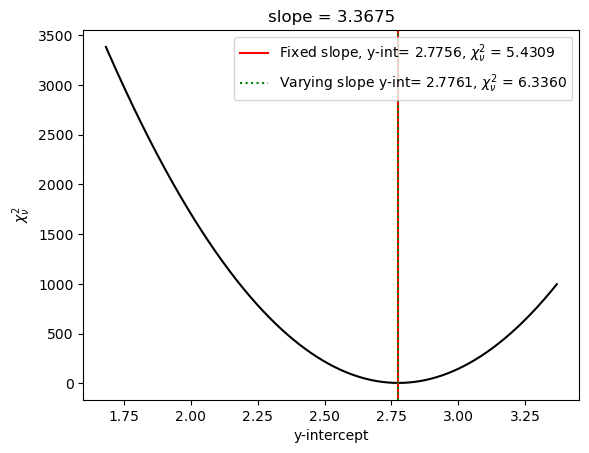

In [391]:
plt.plot(-bs/ie_slope, ie_chi2_fixed, color='k')
plt.axvline(-ie_yint_fixed/ie_slope, color='r', label=fr'Fixed slope, y-int= {-ie_yint_fixed/ie_slope:.4f}, $\chi^2_\nu$ = {ie_chi2_fixed_min:.4f}')
plt.axvline(-ie_yint/ie_slope, color='g', linestyle=':', label=fr'Varying slope y-int= {-ie_yint/ie_slope:.4f}, $\chi^2_\nu$ = {ie_chi2_norm:.4f}')
plt.legend()
plt.xlabel('y-intercept')
plt.ylabel(r'$\chi^2_\nu$')
plt.title(f'slope = {1/ie_slope:.4f}')
# plt.xlim(2.65,2.85)
# plt.ylim(0,50)
plt.savefig(plot_dir + '/paper_plots/' + 'illustris_ellipticals_chi2.png', bbox_inches='tight')

### MaNGA spirals

In [392]:
s_veff = []
s_veff_ctr = []
s_mvis_bins = mvis_bins
s_mvis_bins = np.concatenate((mvis_bins[:1], mvis_bins[3:-6], mvis_bins[-1:]))
indices = np.digitize(HI_s_match['Mstar_MHI_h'], s_mvis_bins)

for i in range(1, len(s_mvis_bins)):

    s_veff.append(np.log10(HI_s_match['V_R90'])[indices==i])
    s_veff_ctr.append(np.mean(HI_s_match['Mstar_MHI_h'][indices==i]))

s_mvis_veff_avg, s_mvis_veff_sig = fit_to_gaussian(s_veff, plot_dir = plot_dir +'/s_mvis_veff_imatch/', 
                                                         plot_name='s_v_eff_mvis', xlab=r'$M_{\rm vis}$')

s_mvis_veff_popt, s_mvis_veff_pcov = curve_fit(lin_fit, s_veff_ctr, 
                                       s_mvis_veff_avg, sigma=s_mvis_veff_sig)

print('best fit values: ')
print(s_mvis_veff_popt[0], ' +- ', np.sqrt(s_mvis_veff_pcov[0,0]))
print(s_mvis_veff_popt[1], ' +- ', np.sqrt(s_mvis_veff_pcov[1][1]))
print('slope: ', 1/s_mvis_veff_popt[0], ' +/- ', 1/s_mvis_veff_popt[0]**2 * s_mvis_veff_pcov[0,0])
err = np.sqrt(s_mvis_veff_pcov[1,1]**2/s_mvis_veff_popt[0]**2 +(s_mvis_veff_popt[1]/s_mvis_veff_popt[0]**2)**2 * s_mvis_veff_pcov[0,0]**2)
print('y-int: ', -s_mvis_veff_popt[1]/s_mvis_veff_popt[0], ' +/- ', err)
s_chi2_norm = chi2_norm(s_mvis_veff_avg, s_mvis_veff_popt[0]*np.array(s_veff_ctr) + s_mvis_veff_popt[1], s_mvis_veff_sig, 2)
print('chi2_nu: ', s_chi2_norm)

best fit values: 
0.2931345593012969  +-  0.006262107969157443
-0.7991329729020924  +-  0.06406173151991999
slope:  3.411402607674638  +/-  0.0004563594591923616
y-int:  2.7261643076369837  +/-  0.014004822913583835
chi2_nu:  1.8844498647577463


#### MCMC

In [393]:
x0 = np.random.uniform(low=[-10,-10], high=[10,10], size=(32,2))
nwalkers, ndim = x0.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=(np.array(s_veff_ctr), s_mvis_veff_avg, s_mvis_veff_sig))
state = sampler.run_mcmc(x0, 10000, progress='notebook')

  0%|          | 0/10000 [00:00<?, ?it/s]

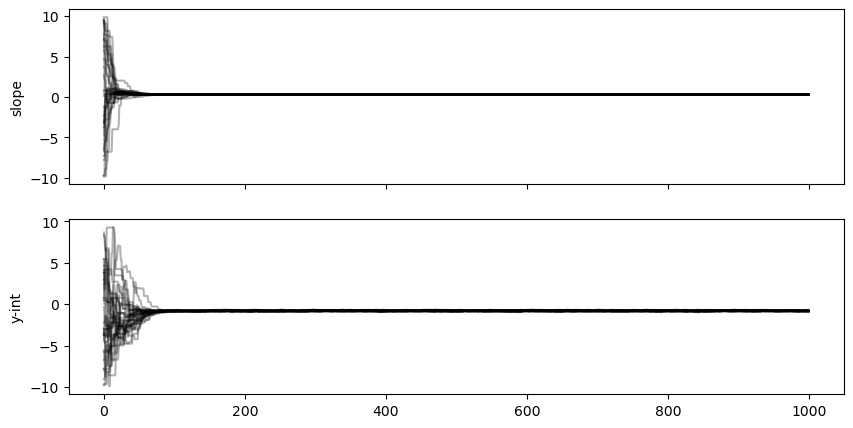

In [394]:
fig, axes = plt.subplots(2,1, figsize=(10,5), sharex=True, gridspec_kw={'hspace':0.2})
samples = sampler.get_chain()
labels = ['slope', 'y-int']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:1000, :, i], 'k', alpha=0.3)
    ax.set_ylabel(labels[i])
    

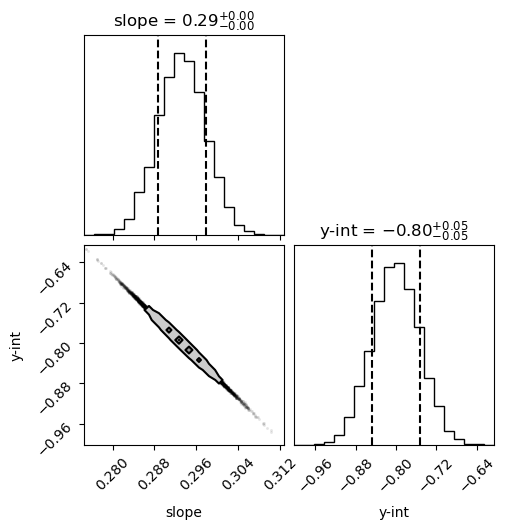

In [395]:
tau = sampler.get_autocorr_time()
flat_samples = sampler.get_chain(discard=100, thin=int(np.max(tau)), flat=True)
fig = corner.corner(flat_samples, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84]
                   # plot_density=1
                   )

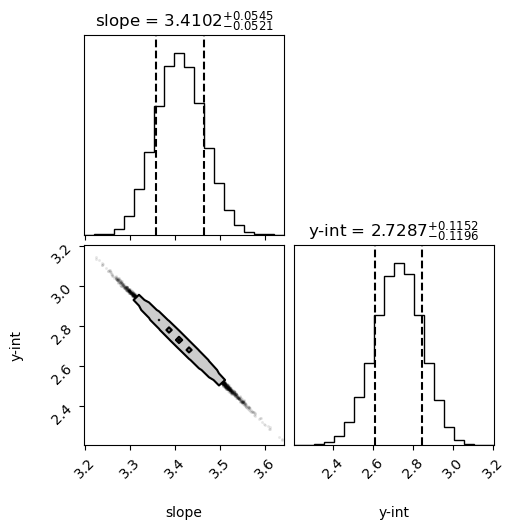

In [396]:
flat_samples_flip = np.array([1/flat_samples[:,0], -flat_samples[:,1]/flat_samples[:,0]]).transpose()
fig = corner.corner(flat_samples_flip, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                    title_fmt='.4f'
                   # plot_density=1
                    
                   )

plt.savefig(plot_dir + '/paper_plots/' + 'manga_spirals_corner.png', bbox_inches='tight')

In [397]:
s_slope = np.percentile(flat_samples[:,0],50)
s_yint = np.percentile(flat_samples[:,1],50)
s_chi2 = chi2_norm(lin_fit(np.array(s_veff_ctr), np.percentile(flat_samples[:,0],50), np.percentile(flat_samples[:,1],50)), s_mvis_veff_avg, s_mvis_veff_sig, 2)
s_chi2

1.8846141458913692

In [398]:
bs = np.linspace(-1,-0.5,10000)
s_chi2_fixed = np.zeros(len(bs))
for i in range(len(bs)):
    s_chi2_fixed[i] = chi2_norm(lin_fit(np.array(s_veff_ctr), s_slope, bs[i]), s_mvis_veff_avg, s_mvis_veff_sig, 1)

In [399]:
s_yint_fixed = bs[np.argmin(s_chi2_fixed)]
s_chi2_fixed_min = np.min(s_chi2_fixed)
print(np.min(s_chi2_fixed))
print(bs[np.argmin(s_chi2_fixed)])

1.570485384177906
-0.8001800180018002


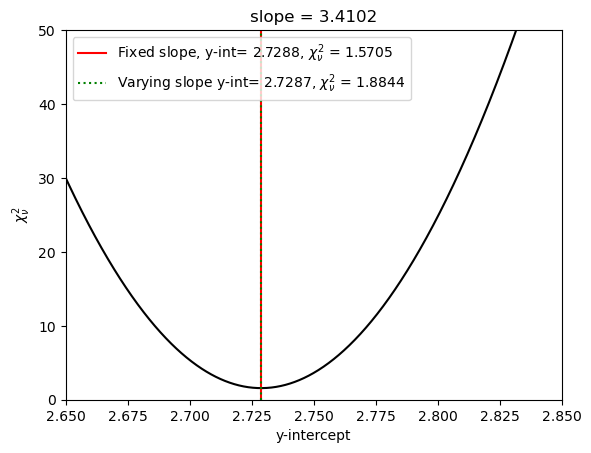

In [401]:
plt.plot(-bs/s_slope, s_chi2_fixed, color='k')
plt.axvline(-s_yint_fixed/s_slope, color='r', label=fr'Fixed slope, y-int= {-s_yint_fixed/s_slope:.4f}, $\chi^2_\nu$ = {s_chi2_fixed_min:.4f}')
plt.axvline(-s_yint/s_slope, color='g', linestyle=':', label=fr'Varying slope y-int= {-s_yint/s_slope:.4f}, $\chi^2_\nu$ = {s_chi2_norm:.4f}')
plt.legend()
plt.xlabel('y-intercept')
plt.ylabel(r'$\chi^2_\nu$')
plt.title(f'slope = {1/s_slope:.4f}')
plt.xlim(2.65,2.85)
plt.ylim(0,50)
plt.savefig(plot_dir + '/paper_plots/' + 'manga_spirals_chi2.png', bbox_inches='tight')

### Illustris spirals

In [402]:
is_veff = []
is_veff_ctr = []
is_mvis_bins = mvis_bins
is_mvis_bins = np.concatenate((mvis_bins[:1], mvis_bins[3:-6], mvis_bins[-1:]))
indices = np.digitize(HI_s_match['illustris_Mstar_MHI_h'], is_mvis_bins)

for i in range(1, len(is_mvis_bins)):

    is_veff.append(np.log10(HI_s_match['illustris_Vmax'])[indices==i])
    is_veff_ctr.append(np.mean(HI_s_match['illustris_Mstar_MHI_h'][indices==i]))

is_mvis_veff_avg, is_mvis_veff_sig = fit_to_gaussian(is_veff, plot_dir = plot_dir +'/is_mvis_veff_imatch/', 
                                                         plot_name='s_v_eff_mvis', xlab=r'$M_{\rm vis}$')

is_mvis_veff_popt, is_mvis_veff_pcov = curve_fit(lin_fit, is_veff_ctr, 
                                       is_mvis_veff_avg, sigma=is_mvis_veff_sig)

print('best fit values: ')
print(is_mvis_veff_popt[0], ' +- ', np.sqrt(is_mvis_veff_pcov[0,0]))
print(is_mvis_veff_popt[1], ' +- ', np.sqrt(is_mvis_veff_pcov[1][1]))
print('slope: ', 1/is_mvis_veff_popt[0], ' +/- ', 1/is_mvis_veff_popt[0]**2 * is_mvis_veff_pcov[0,0])
err = np.sqrt(is_mvis_veff_pcov[1,1]**2/is_mvis_veff_popt[0]**2 +(is_mvis_veff_popt[1]/is_mvis_veff_popt[0]**2)**2 * is_mvis_veff_pcov[0,0]**2)
print('y-int: ', -is_mvis_veff_popt[1]/is_mvis_veff_popt[0], ' +/- ', err)
is_chi2_norm = chi2_norm(is_mvis_veff_avg, is_mvis_veff_popt[0]*np.array(is_veff_ctr) + is_mvis_veff_popt[1], is_mvis_veff_sig, 2)
print('chi2_nu: ', is_chi2_norm)

best fit values: 
0.2555687506380087  +-  0.007649626605176373
-0.41369429266698365  +-  0.07691911830459539
slope:  3.9128414467871093  +/-  0.0008959112165004177
y-int:  1.6187201746466502  +/-  0.023153491716221386
chi2_nu:  21.381544111416922


#### MCMC

In [403]:
x0 = np.random.uniform(low=[-10,-10], high=[10,10], size=(32,2))
nwalkers, ndim = x0.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=(np.array(is_veff_ctr), is_mvis_veff_avg, is_mvis_veff_sig))
state = sampler.run_mcmc(x0, 10000, progress='notebook')

  0%|          | 0/10000 [00:00<?, ?it/s]

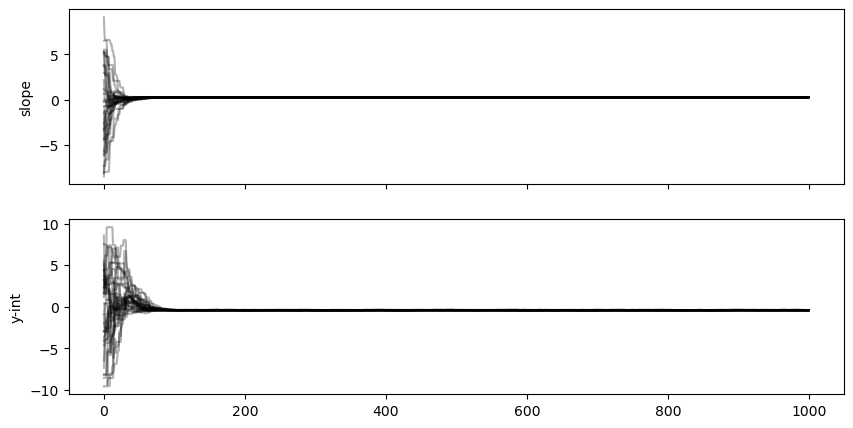

In [404]:
fig, axes = plt.subplots(2,1, figsize=(10,5), sharex=True, gridspec_kw={'hspace':0.2})
samples = sampler.get_chain()
labels = ['slope', 'y-int']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:1000, :, i], 'k', alpha=0.3)
    ax.set_ylabel(labels[i])
    

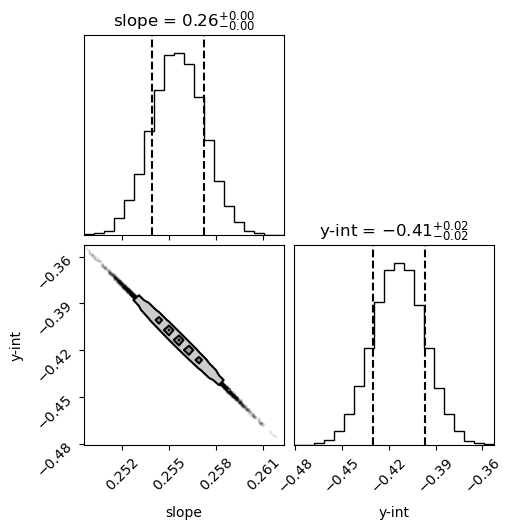

In [405]:
tau = sampler.get_autocorr_time()
flat_samples = sampler.get_chain(discard=100, thin=int(np.max(tau)), flat=True)
fig = corner.corner(flat_samples, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                     show_titles=1,
                    title_quantiles = [0.16,0.5,0.84]
                   # plot_density=1
                   )

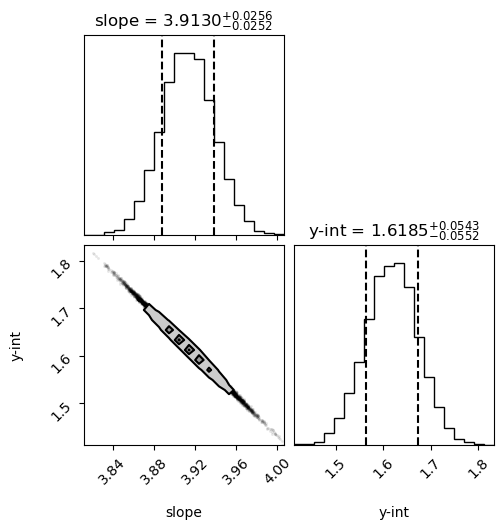

In [406]:
flat_samples_flip = np.array([1/flat_samples[:,0], -flat_samples[:,1]/flat_samples[:,0]]).transpose()
fig = corner.corner(flat_samples_flip, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                    title_fmt='.4f'
                   # plot_density=1
                    
                   )

plt.savefig(plot_dir + '/paper_plots/' + 'illustris_spirals_corner.png', bbox_inches='tight')

In [407]:
is_slope = np.percentile(flat_samples[:,0],50)
is_yint = np.percentile(flat_samples[:,1],50)
is_chi2 = chi2_norm(lin_fit(np.array(is_veff_ctr), np.percentile(flat_samples[:,0],50), np.percentile(flat_samples[:,1],50)), is_mvis_veff_avg, is_mvis_veff_sig, 2)
is_chi2

21.381871473719535

In [408]:
bs = np.linspace(-1,0,10000)
is_chi2_fixed = np.zeros(len(bs))
for i in range(len(bs)):
    is_chi2_fixed[i] = chi2_norm(lin_fit(np.array(is_veff_ctr), is_slope, bs[i]), is_mvis_veff_avg, is_mvis_veff_sig, 1)

In [409]:
is_yint_fixed = bs[np.argmin(is_chi2_fixed)]
is_chi2_fixed_min = np.min(is_chi2_fixed)
print(np.min(is_chi2_fixed))
print(bs[np.argmin(is_chi2_fixed)])

17.818153246243256
-0.4136413641364136


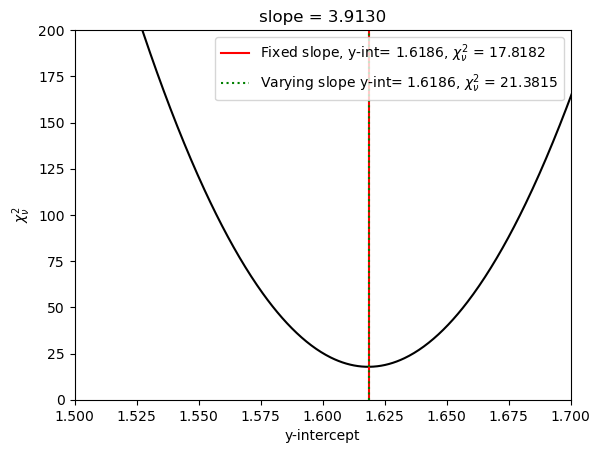

In [411]:
plt.plot(-bs/is_slope, is_chi2_fixed, color='k')
plt.axvline(-is_yint_fixed/is_slope, color='r', label=fr'Fixed slope, y-int= {-is_yint_fixed/is_slope:.4f}, $\chi^2_\nu$ = {is_chi2_fixed_min:.4f}')
plt.axvline(-is_yint/is_slope, color='g', linestyle=':', label=fr'Varying slope y-int= {-is_yint/is_slope:.4f}, $\chi^2_\nu$ = {is_chi2_norm:.4f}')
plt.legend()
plt.xlabel('y-intercept')
plt.ylabel(r'$\chi^2_\nu$')
plt.title(f'slope = {1/is_slope:.4f}')
plt.xlim(1.5,1.7)
plt.ylim(0,200)
plt.savefig(plot_dir + '/paper_plots/' + 'illustris_spirals_chi2.png', bbox_inches='tight')

### Plots

In [412]:
ms = np.linspace(8,13,100)
vs = np.linspace(1,3,100)

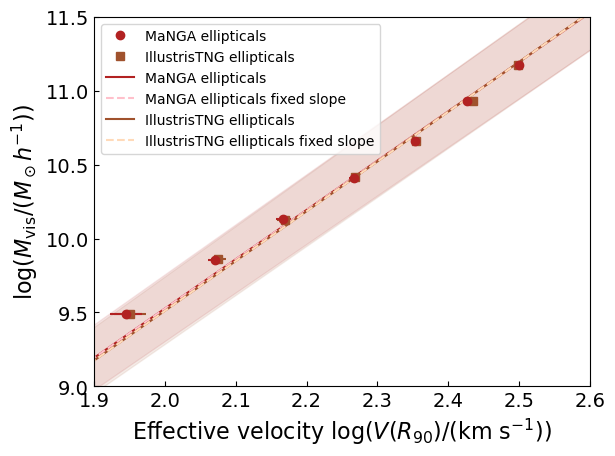

In [414]:


plt.fill_between(vs, vs*(3.3673+0.0525) + 2.7764+0.1225,vs*(3.3673-0.0505) + 2.7764-0.1285, color='sienna', alpha=0.1)

plt.fill_between(vs, vs*(3.3341+0.0522) + 2.8589+0.1209,vs*(3.3341-0.0498) + 2.8589-0.1267, color='firebrick', alpha=0.1)

plt.errorbar(ie_mvis_veff_avg, ie_veff_ctr, xerr=ie_mvis_veff_sig,
            linestyle='none', marker='s', color='sienna')
plt.errorbar(e_mvis_veff_avg, e_veff_ctr, xerr=e_mvis_veff_sig, 
             linestyle='none', marker='o', color='firebrick')



plt.plot(ms*e_slope + e_yint, ms, color='firebrick')
plt.plot(ms*e_slope + e_yint_fixed, ms, color='pink', linestyle='--')
plt.plot(ms*ie_slope + ie_yint, ms, color='sienna', linestyle='-')
plt.plot(ms*ie_slope + ie_yint_fixed, ms, color='peachpuff',linestyle='--')


legend_elements = [Line2D([0], [0], marker='o', color='w', label='MaNGA ellipticals',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6),
                   Line2D([0], [0], marker='s', color='w', label='IllustrisTNG ellipticals',
                          markeredgecolor='sienna', markerfacecolor='sienna', markersize=6),
                   Line2D([0], [0], marker='none', color='firebrick', label='MaNGA ellipticals',
                          markeredgecolor='firebrick', markersize=6),
                   Line2D([0], [0], marker='none', color='pink', label='MaNGA ellipticals fixed slope',
                          markeredgecolor='pink', linestyle='--',markersize=6),
                   Line2D([0], [0], marker='none', color='sienna', label='IllustrisTNG ellipticals',
                          markeredgecolor='sienna', markerfacecolor='sienna', markersize=6),
                   Line2D([0], [0], marker='none', color='peachpuff', label='IllustrisTNG ellipticals fixed slope',
                          markeredgecolor='peachpuff', markerfacecolor='sienna', linestyle='--',markersize=6),
                   
                  # Line2D([0], [0], marker='s', color='w', label='IllustrisTNG spiral mean',
                  #         markeredgecolor='blueviolet', markerfacecolor='blueviolet', markersize=6),
                  #  Line2D([0], [0], marker='s', color='w', label='IllustrisTNG elliptical mean',
                  #         markeredgecolor='sienna', markerfacecolor='sienna', markersize=6),
                  # Line2D([0], [0], marker='^', color='w', label='MaNGA spiral mean',
                  #         markeredgecolor='navy', markerfacecolor='navy', markersize=6),
                  # Line2D([0], [0], marker='o', color='w', label='MaNGA elliptical mean',
                  #         markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6)
                  ]

plt.legend(handles=legend_elements)


plt.xlim(1.9,2.6)
plt.ylim(9,11.5)

plt.tick_params( axis='both', direction='in', labelsize=14)
plt.xlabel(r'Effective velocity $\log(V(R_{90})/(\text{km s}^{-1}))$', fontsize=16)
plt.ylabel(r'$\log(M_{\rm vis}/(M_\odot h^{-1}))$', fontsize=16)

plt.savefig(plot_dir + '/paper_plots/' + 'ellipticals_BTFR_slopes_v2.png', bbox_inches='tight')

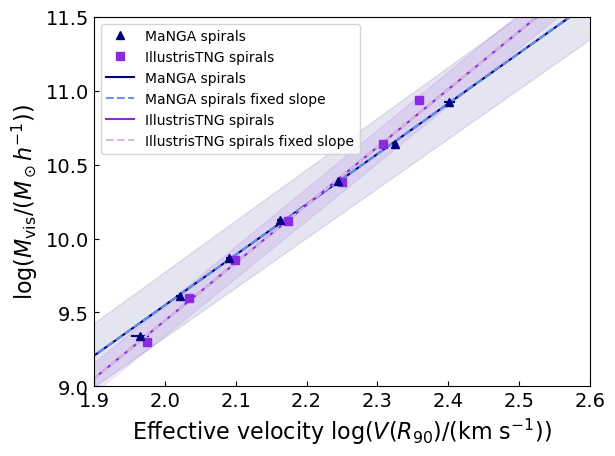

In [353]:

plt.fill_between(vs, vs*(3.9127+0.0254) + 1.6190+0.0535,vs*(3.9127-0.0248) + 1.6190-0.0550, color='blueviolet', alpha=0.1)

plt.fill_between(vs, vs*(3.4117+0.0526) + 2.7253+0.1161,vs*(3.4117-0.0525) + 2.7253-0.1160, color='navy', alpha=0.1)


plt.errorbar(is_mvis_veff_avg, is_veff_ctr, xerr=is_mvis_veff_sig,
            linestyle='none', marker='s', color='blueviolet')
plt.errorbar(s_mvis_veff_avg, s_veff_ctr, xerr=s_mvis_veff_sig, 
             linestyle='none', marker='^', color='navy')



plt.plot(ms*s_slope + s_yint, ms, color='navy')
plt.plot(ms*s_slope + s_yint_fixed, ms, color='cornflowerblue', linestyle='--')
plt.plot(ms*is_slope + is_yint, ms, color='blueviolet', linestyle='-')
plt.plot(ms*is_slope + is_yint_fixed, ms, color='thistle',linestyle='--')

legend_elements = [Line2D([0], [0], marker='^', color='w', label='MaNGA spirals',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6),
                   Line2D([0], [0], marker='s', color='w', label='IllustrisTNG spirals',
                          markeredgecolor='blueviolet', markerfacecolor='blueviolet', markersize=6),
                   Line2D([0], [0], marker='none', color='navy', label='MaNGA spirals',
                          markeredgecolor='navy', markersize=6),
                   Line2D([0], [0], marker='none', color='cornflowerblue', label='MaNGA spirals fixed slope',
                          markeredgecolor='cornflowerblue', linestyle='--',markersize=6),
                   Line2D([0], [0], marker='none', color='blueviolet', label='IllustrisTNG spirals',
                          markeredgecolor='blueviolet', markerfacecolor='blueviolet', markersize=6),
                   Line2D([0], [0], marker='none', color='thistle', label='IllustrisTNG spirals fixed slope',
                          markeredgecolor='thistle', linestyle='--',markersize=6),
                  ]




plt.legend(handles=legend_elements)


plt.xlim(1.9,2.6)
plt.ylim(9,11.5)

plt.tick_params( axis='both', direction='in', labelsize=14)
plt.xlabel(r'Effective velocity $\log(V(R_{90})/(\text{km s}^{-1}))$', fontsize=16)
plt.ylabel(r'$\log(M_{\rm vis}/(M_\odot h^{-1}))$', fontsize=16)
plt.savefig(plot_dir + '/paper_plots/' + 'spirals_BTFR_slopes_v2.png', bbox_inches='tight')